In [1]:
import numpy as np 


In [2]:

import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin1')
df.head()




,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
#data cleaning
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace= True)
df.sample(5)

,v1,v2
3334,ham,"Sorry, got a late start, we're on the way"
4411,ham,If i said anything wrong sorry de:-)
4104,ham,Jus finish my lunch on my way home lor... I to...
2809,ham,Mm so you asked me not to call radio
4018,spam,U've been selected to stay in 1 of 250 top Bri...


In [5]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3585,spam,I am hot n horny and willing I live local to y...
5416,ham,My slave! I want you to take 2 or 3 pictures o...
3531,ham,"Actually, my mobile is full of msg. And i m do..."
802,spam,FREE for 1st week! No1 Nokia tone 4 ur mobile ...
2822,ham,Then u ask darren go n pick u lor... But i oso...


In [6]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [7]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
#to check missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [9]:
#for duplicte value
df.duplicated().sum()

np.int64(403)

In [10]:
df=df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(5169, 2)

In [12]:
#2 EDA
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

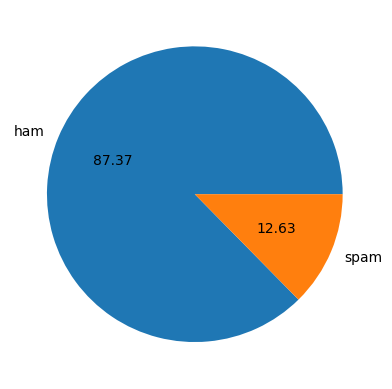

In [13]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [14]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\panka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
df['num_char']=df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [16]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\panka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
#num of words
df['num']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [18]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [19]:
df.head()

,target,text,num_char,num,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [20]:
df[['num_char','num','num_sentences']].describe()

,num_char,num,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [21]:
#ham
df[df['target']==0][['num_char','num','num_sentences']].describe()

,num_char,num,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [22]:
#spam
df[df['target']==1][['num_char','num','num_sentences']].describe()

,num_char,num,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [23]:
import seaborn as sns


<Axes: xlabel='num', ylabel='Count'>

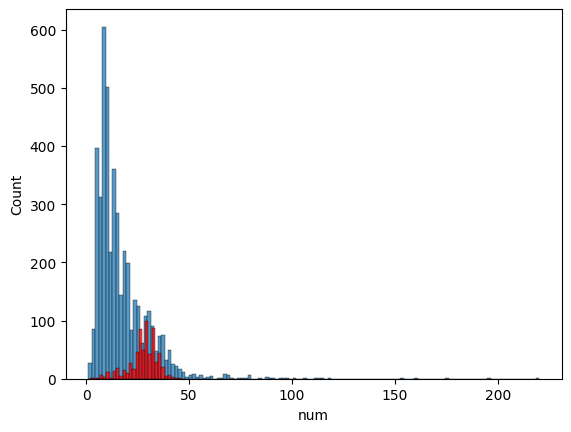

In [24]:
sns.histplot(df[df['target']==0]['num'])
sns.histplot(df[df['target']==1]['num'],color='red')

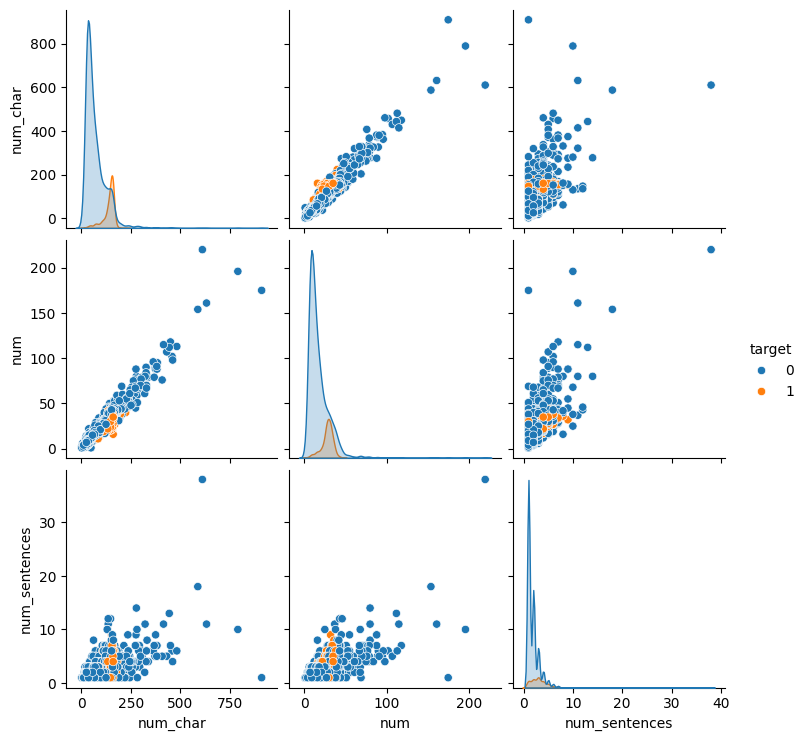

In [25]:
sns.pairplot(df,hue='target')

<Axes: >

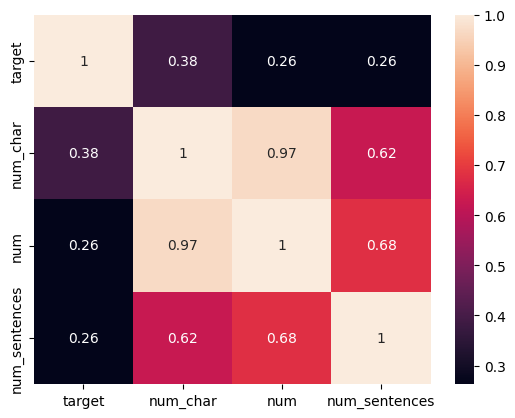

In [26]:
# Filter only the numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Create heatmap with only numeric columns
sns.heatmap(numeric_df.corr(), annot=True)

# If you need to analyze text columns, you'll need to convert them first
# For example, if working with text classification data:
# from sklearn.feature_extraction.text import CountVectorizer
# vectorizer = CountVectorizer()
# X = vectorizer.fit_transform(df['text_column'])

In [27]:
#3 data preprocessing
import nltk
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
def transform_text(text):
    ps = PorterStemmer()
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\panka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
from nltk.stem.porter import PorterStemmer

In [29]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")


'gon na home soon want talk stuff anymor tonight k cri enough today'

In [30]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [31]:
# Import the necessary library first
from nltk.stem import PorterStemmer

# Define the transform_text function
def transform_text(text):
    # Define ps if it's needed in this function
    ps = PorterStemmer()  # Now this will work because we've imported it
    
    # Add your text transformation logic here
    # This is just a placeholder example:
    transformed = text.lower()  # Convert to lowercase
    # Other transformations you might want to do...
    
    return transformed

# Now you can use the function
transformed_text = transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")
print(transformed_text)

# Note: If you need to use a DataFrame, make sure to uncomment and properly define it:
# import pandas as pd
# df = pd.read_csv('your_data.csv')
# print(df['text'][10])

i'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? i've cried enough today.


In [32]:
# First, define the transform_text function
def transform_text(text):
    # Define ps if it's needed in this function
    # For example, if ps was supposed to be a preprocessing step:
    ps = PorterStemmer()  # You might need to import this: from nltk.stem import PorterStemmer
    
    # Add your text transformation logic here
    # This is just a placeholder example:
    transformed = text.lower()  # Convert to lowercase
    # Other transformations you might want to do...
    
    return transformed

# Make sure df is defined (if it's a pandas DataFrame)
# import pandas as pd
# df = pd.read_csv('your_data.csv')  # Uncomment and modify as needed

# Now you can use the function
transformed_text = transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")
print(transformed_text)

# And access the DataFrame
# print(df['text'][10])  # Uncomment if df is properly defined

i'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? i've cried enough today.


In [33]:

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')



'love'

In [34]:
df['transformed_text'] = df['text'].apply(transform_text)

In [35]:
df.head()

,target,text,num_char,num,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i don't think he goes to usf, he lives aro..."


In [36]:
!pip install wordcloud

In [37]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [38]:
spam_wc= wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

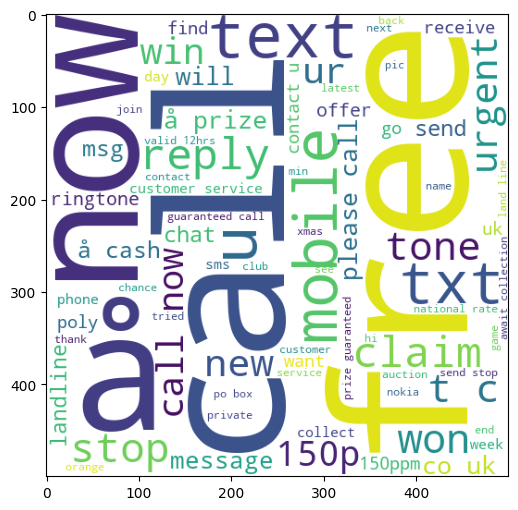

In [39]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [40]:
spam_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

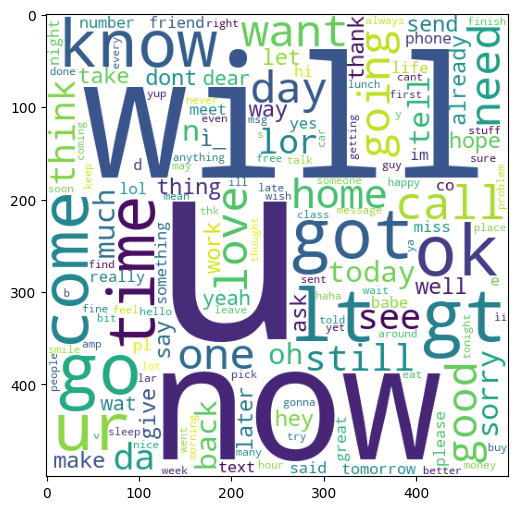

In [41]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [42]:
df.head()

,target,text,num_char,num,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i don't think he goes to usf, he lives aro..."


In [43]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [44]:
len(spam_corpus)

15464

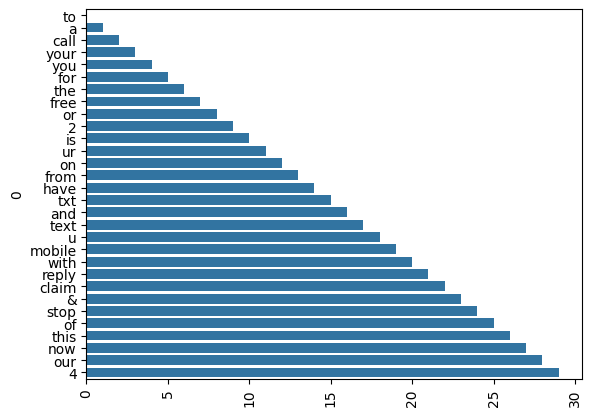

In [45]:


from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.show()



In [46]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [47]:
len(ham_corpus)

63832

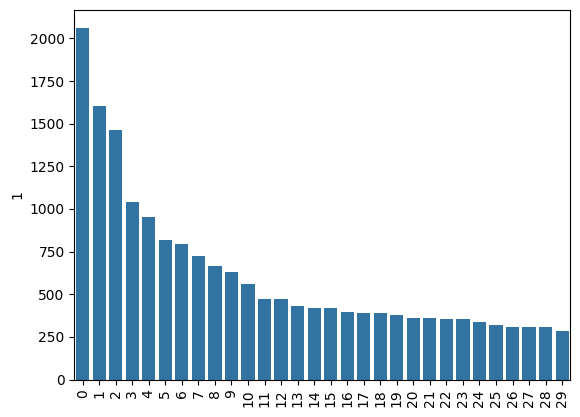

In [48]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [49]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_char,num,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i don't think he goes to usf, he lives aro..."


In [50]:
#4 model building


from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)



In [51]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [52]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)
# appending the num_character col to X
#X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [53]:
X.shape

(5169, 3000)

In [54]:
df.head()

,target,text,num_char,num,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i don't think he goes to usf, he lives aro..."


In [55]:
#model building
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [56]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [57]:
X.shape

(5169, 3000)

In [58]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=2)

In [61]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [62]:
gnb=GaussianNB()
mnb=MultinomialNB() 
bnb=BernoulliNB()

In [63]:


gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))



0.9003868471953579
[[806  90]
 [ 13 125]]
0.5813953488372093


In [64]:




mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))




0.9874274661508704
[[893   3]
 [ 10 128]]
0.9770992366412213


In [65]:


bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))



0.9845261121856866
[[893   3]
 [ 13 125]]
0.9765625


In [66]:
!pip install xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [67]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [68]:


clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}



In [69]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [70]:


train_classifier(svc,X_train,y_train,X_test,y_test)



(0.9777562862669246, 0.967479674796748)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9777562862669246
Precision -  0.967479674796748
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9874274661508704
Precision -  0.9770992366412213
For  DT
Accuracy -  0.9400386847195358
Precision -  0.8958333333333334
For  LR
Accuracy -  0.9738878143133463
Precision -  0.9663865546218487
For  RF
Accuracy -  0.9777562862669246
Precision -  1.0
For  AdaBoost
Accuracy -  0.9468085106382979
Precision -  0.9662921348314607


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

In [ ]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
#model improve
#change max_feature to tfdf
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

new_df = performance_df.merge(temp_df,on='Algorithm')

new_df_scaled = new_df.merge(temp_df,on='Algorithm')

temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

new_df_scaled.merge(temp_df,on='Algorithm')



In [ ]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [ ]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

voting.fit(X_train,y_train)



In [ ]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

In [ ]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

In [ ]:

from sklearn.ensemble import StackingClassifier

clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)


clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))




In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import pickle

# load dataset
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

# vectorizer
cv = CountVectorizer()
X = cv.fit_transform(df['text'])
y = df['label']

# model
model = MultinomialNB()
model.fit(X, y)

# save vectorizer and model
pickle.dump(cv, open('vectorizer1.pkl', 'wb'))  # Changed tfidf to cv
pickle.dump(model, open('model1.pkl', 'wb')) 
pickle.dump(encoder, open('label_encoder.pkl', 'wb'))# Changed mnb to model

tf = pickle.load(open('vectorizer1.pkl','rb'))
md = pickle.load(open('model1.pkl','rb'))

# test transform + predict (use first row of your text column)
sample_vec = tf.transform([df['text'].iloc[0]])  # Changed 'transformed_text' to 'text'
print("Predict ->", md.predict(sample_vec)[0], "   classes_ ->", getattr(md, "classes_", None))
print("classes_ ->", getattr(md, "classes_", None))
print("label encoder classes:", le.classes_)
print("Model saved successfully!")

In [ ]:
# create_vectorizer.py
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Provide your training corpus here:
# Option A: load from CSV
# import pandas as pd
# df = pd.read_csv("train.csv")    # ensure column 'text' exists
# train_texts = df['text'].astype(str).tolist()

# Option B: quick example
train_texts = [
    "free message click here",
    "hello how are you",
    "win a prize now",
    "meeting at 10am"
    # <-- replace with your real training texts
]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf.fit(train_texts)

with open("vectorizer1.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved vectorizer1.pkl (scikit-learn compatible).")


In [ ]:
# Assistant
# recreate_vectorizer.py
import pickle
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Specify an encoding that can handle the file's content
# Common alternatives are 'latin1', 'ISO-8859-1', or 'cp1252'
df = pd.read_csv("spam.csv", encoding='latin1')   # Using latin1 encoding which is more permissive

# First, let's check what columns are actually in the DataFrame
print(df.columns)

# Assuming the message content is in a column named 'v2' (common in spam datasets)
# and the label is in a column named 'v1' (where 'spam' and 'ham' are typical values)
texts = df['v2'].astype(str).tolist()  # Changed 'text' to 'v2'
labels = df['v1'].tolist()  # Changed 'label' to 'v1'

vec = TfidfVectorizer(max_features=5000)
X = vec.fit_transform(texts)

model = MultinomialNB()
model.fit(X, labels)

with open("vectorizer1.pkl","wb") as f:
    pickle.dump(vec, f)

with open("model1.pkl","wb") as f:
    pickle.dump(model, f)

In [2]:
def get_spam_probability(model1, vectorizer1, text):
    # Convert text to vector
    text_vector = vectorizer.transform([text])
    
    # Get probability (1 = spam)
    prob = model.predict_proba(text_vector)[0][1]

    return prob
